In [1]:
import rospy
import ipywidgets as widgets
import actionlib
from IPython.display import display, clear_output
from geometry_msgs.msg import Point, Pose, Twist, PoseStamped
import assignment_2_2024.msg
import threading
from sensor_msgs.msg import LaserScan
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from actionlib_msgs.msg import GoalStatus
from nav_msgs.msg import Odometry
import random
from std_srvs.srv import Empty
from time import sleep
from gazebo_msgs.srv import SetModelState
from gazebo_msgs.msg import ModelState

In [2]:
%matplotlib notebook
action_client = actionlib.SimpleActionClient('/reaching_goal', 
                                                      assignment_2_2024.msg.PlanningAction)


In [3]:
def get_reset_state_msg():
    state_msg = ModelState()
    state_msg.model_name = 'robot1'
    state_msg.pose.position.x = 0
    state_msg.pose.position.y = 1
    state_msg.pose.position.z = 0.1
    # Set orientation if needed
    state_msg.pose.orientation.x = 0
    state_msg.pose.orientation.y = 0
    state_msg.pose.orientation.z = 0
    state_msg.pose.orientation.w = 1
    return state_msg


In [4]:
reached_goals_number = 0
all_goals_number = 0
def reset_simulation():
    global x_input,y_input
    x_input.value = round(random.uniform(-7, 7), 2)
    y_input.value = round(random.uniform(-7, 7), 2)
    
    rospy.wait_for_service('/gazebo/set_model_state')
    try:
        reset_sim = rospy.ServiceProxy('/gazebo/set_model_state', SetModelState)
        msg = get_reset_state_msg()
        reset_sim(msg)
        rospy.loginfo("Gazebo model has been reset.")
    except rospy.ServiceException as e:
        rospy.logerr("Service call failed: %s", e)
    sleep(3)
    rospy.loginfo(f'New target position is {x_input.value},{y_input.value} ')
    set_goal(0)

In [14]:
class Visualizer:
    def __init__(self):
        self.x_data = []
        self.y_data = []
        
        self.fig, (self.ax_traj, self.ax_bar) = plt.subplots(2, 1, figsize=(5, 10))
        self.line, = self.ax_traj.plot([], [], '-b')
        
        self.ax_traj.set_xlim(-20, 20)
        self.ax_traj.set_ylim(-20, 20)
        self.ax_traj.set_xlabel('X Position')
        self.ax_traj.set_ylabel('Y Position')
        self.ax_traj.set_title('Robot Trajectory')
        
        self.bar_values = [0, 0]
        self.bar_container = self.ax_bar.bar(["Reached","Not reached"], [0,0], color=['blue', 'orange'])
        self.ax_bar.set_ylim(0, 100)
        self.ax_bar.set_title('Current Goals State')
        
    def odom_callback(self, msg):
        # Extract position from Odometry
        x = msg.pose.pose.position.x
        y = msg.pose.pose.position.y
        self.x_data.append(x)
        self.y_data.append(y)
        
        
        
    def init_plot(self):
        return self.line, self.bar_container.patches
    
    def update_plot(self,frame):
        self.line.set_data(self.x_data, self.y_data)
        self.bar_values = [reached_goals_number,all_goals_number-reached_goals_number]
        for bar, new_val in zip(self.bar_container, self.bar_values):
            bar.set_height(new_val)
        return self.line,self.bar_container.patches
        


In [6]:
%matplotlib widget
rospy.init_node("bug_client_py")


In [7]:
start_time = rospy.get_rostime()
# 2 minutes timeout
timeout = rospy.Duration(240)
def bug_client(goal):
    """
    Sends a goal to the action server and waits for the result.
    
    Args:
        goal (Pose): Target position for the robot.
    
    Returns:
        PlanningResult: The result from the action server.
    """
    global reached_goals_number
    action_client.wait_for_server()

    new_goal = PoseStamped()
    new_goal.pose = goal
    new_goal.header.stamp = rospy.Time.now()
    new_goal.header.frame_id = "odom"
    
    goal = assignment_2_2024.msg.PlanningGoal(target_pose=new_goal)

    action_client.send_goal(goal, feedback_cb=feedback_callback)
    action_client.wait_for_result()
    
    state = action_client.get_state()

    if state == GoalStatus.SUCCEEDED:
        reached_goals_number += 1
        reset_simulation()
    return action_client.get_result()

def feedback_callback(feedback):
    """
    Callback function to handle feedback from the action server.
    
    Args:
        feedback (PlanningFeedback): Feedback message from the action server.
    """
    global current_state,current_x,current_y,start_time, timeout

    current_state.value = f"current_state: {feedback.stat}"
    current_x.value = f"current_x: {feedback.actual_pose.position.x}"
    current_y.value = f"current_y: {feedback.actual_pose.position.y}"
    
    current_time = rospy.get_rostime()
    elapsed_time = current_time - start_time
    if elapsed_time > timeout:
        cancel_goal(0)
        reset_simulation()
    



def cancel_goal(a):
    global action_client,output
    with output:
        clear_output()
        action_client.cancel_goal()
        print(f"Cancel goal")

def set_goal(a):
    global x_input,y_input,output,all_goals_number, start_time
    all_goals_number+=1
    with output:
        clear_output()
        goal = Pose()
        # Set position
        goal.position.x = x_input.value
        goal.position.y = y_input.value
        start_time = rospy.get_rostime()
        threading.Thread(target=bug_client,args=(goal,)).start()
        
        print(f"Set bot's x: {x_input.value} and y: {y_input.value}")

In [8]:
def clbk_laser(msg):
    """
    Callback function to process laser scan data and update obstacle regions.
    
    Args:
        msg (sensor_msgs/LaserScan): The laser scan message containing distance readings.
    """
    global min_obstacle_dist
    min_obstacle_dist.value = f"min obstacle dist: {min(msg.ranges)}"

In [9]:
min_obstacle_dist = widgets.Label(
    value = "min obstacle dist: ",
)
laser_scan_sub = rospy.Subscriber('/scan', LaserScan, clbk_laser)

<IPython.core.display.Javascript object>


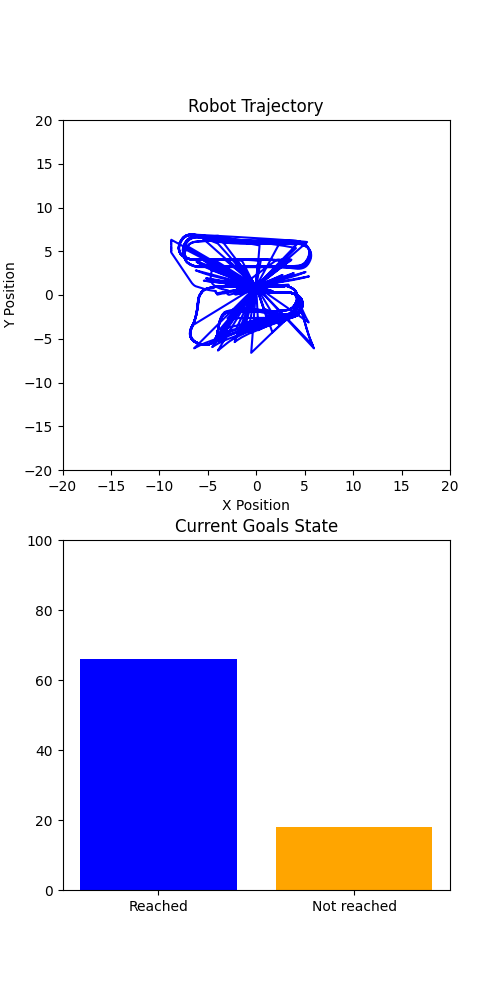

Label(value='current_state: State 0: go to point')

Label(value='current_x: -3.644873667151377')

Label(value='current_y: -3.9049923521400722')

Label(value='min obstacle dist: 0.43437322974205017')

Button(button_style='success', description='Set Goal', style=ButtonStyle())

Button(button_style='success', description='Clear Goal', style=ButtonStyle())

Output()

In [16]:
x_input = widgets.FloatText(
    value=0,
    description='x:',
)

y_input = widgets.FloatText(
    value=0,
    description='y:',
)

current_x = widgets.Label(
    value='current_x: ',
)
current_y = widgets.Label(
    value='current_y: ',
)

current_state = widgets.Label(
    value = "current_state: ",
)
output = widgets.Output()

set_goal_button = widgets.Button(
    description='Set Goal',
    button_style='success'
)
clear_goal_button = widgets.Button(
    description='Clear Goal',
    button_style='success'
)


vis = Visualizer()
sub = rospy.Subscriber('/odom', Odometry, vis.odom_callback)
ani = FuncAnimation(vis.fig, vis.update_plot, init_func=vis.init_plot)
set_goal_button.on_click(set_goal)
clear_goal_button.on_click(cancel_goal)
display(widgets.HBox([x_input, y_input])
        ,current_state, current_x, current_y,min_obstacle_dist,
        set_goal_button,clear_goal_button,output)
plt.show(block=True)


<IPython.core.display.Javascript object>


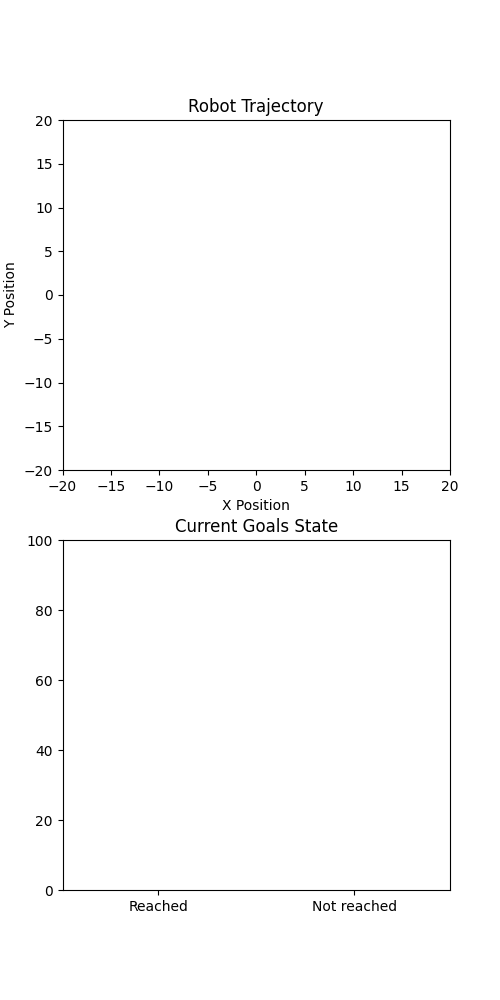

In [15]:
vis = Visualizer()


In [12]:
reset_simulation()

[INFO] [1747734235.333284, 1215.047000]: Gazebo model has been reset.
[INFO] [1747734238.339441, 1218.044000]: New target position is -4.9,-6.11 
